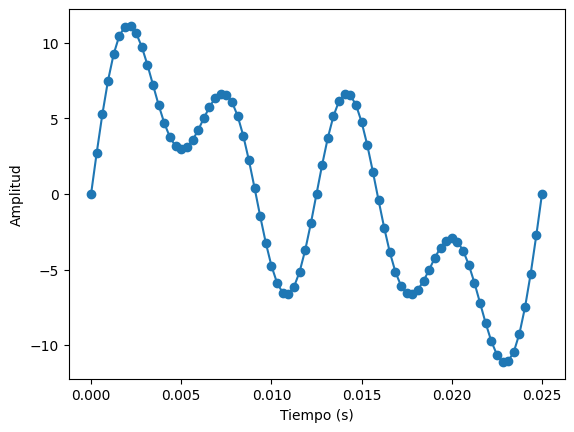

In [19]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

Fo = 40 # Frecuencia fundamental de la señal1
Fo1 = 80 # Frecuencia fundamental de la señal2
Fo2 = 160 # Frecuencia fundamental de la señal3
Tp= 1/40 # Periodo de la señal
Fs = 20*Fo2 # Frecuencia de muestreo-->investigar
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más
A = 5
A1 = 5
A2 = 5
x = A*np.sin(2*np.pi*Fo*t)
x1 = A1*np.sin(2*np.pi*Fo1*t)
x2 = A2*np.sin(2*np.pi*Fo2*t)
xt=x+x1+x2
plt.plot(t, xt, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

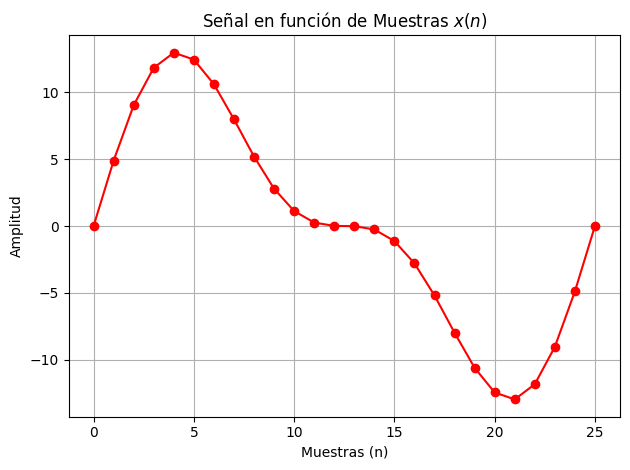

In [6]:
# 1. Frecuencias digitales normalizadas (fo = Fo / Fs)
fo1 = Fo / Fs
fo2 = Fo1 / Fs
fo3 = Fo2 / Fs

# 2. Vector de muestras (n) desde 0 hasta el largo del vector de tiempo anterior
n = np.arange(0, len(t))

# 3. Generación de la señal usando n y las frecuencias normalizadas
x_n1 = A * np.sin(2 * np.pi * fo1 * n)
x_n2 = A1 * np.sin(2 * np.pi * fo2 * n)
x_n3 = A2 * np.sin(2 * np.pi * fo3 * n)
xn = x_n1 + x_n2 + x_n3

# Gráfica en muestras

plt.plot(n, xn, marker='o', color='r')
plt.title('Señal en función de Muestras $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

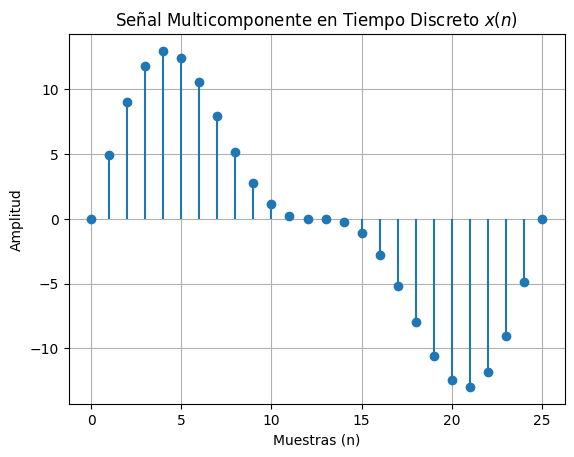

In [8]:
# Usamos stem en lugar de plot para ver los pulsos discretos
plt.stem(n, xn, basefmt=" ")

plt.title('Señal Multicomponente en Tiempo Discreto $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

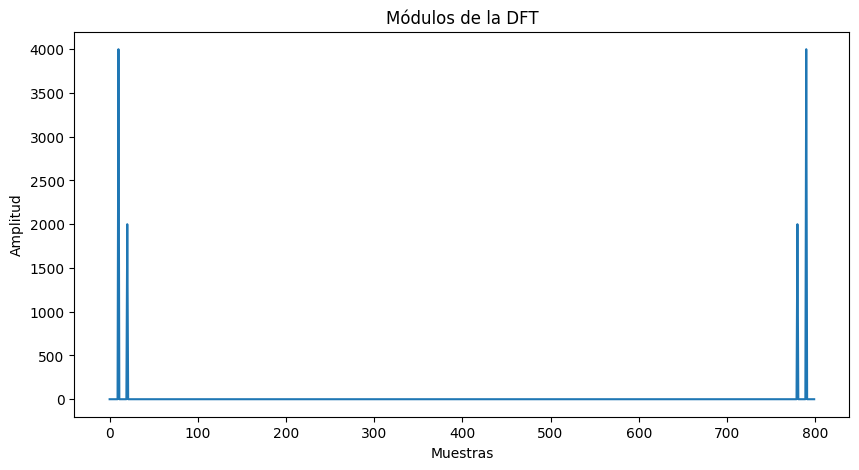

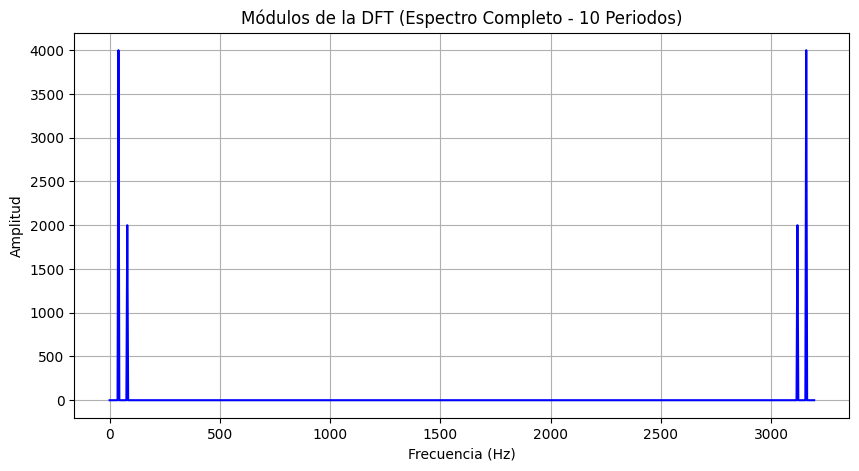

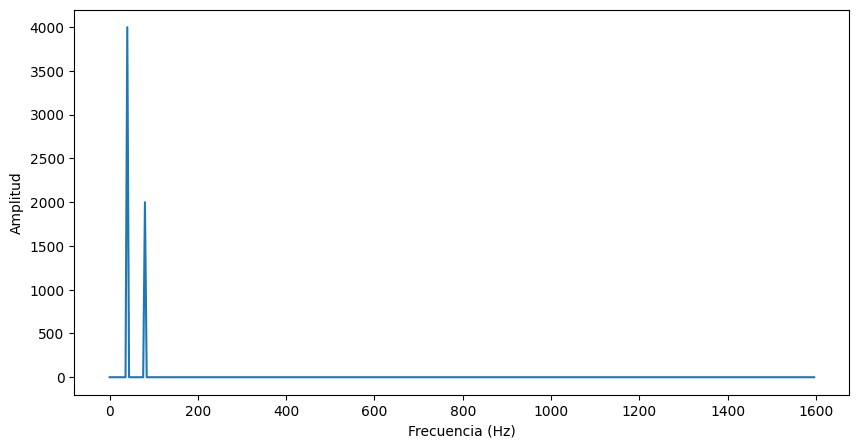

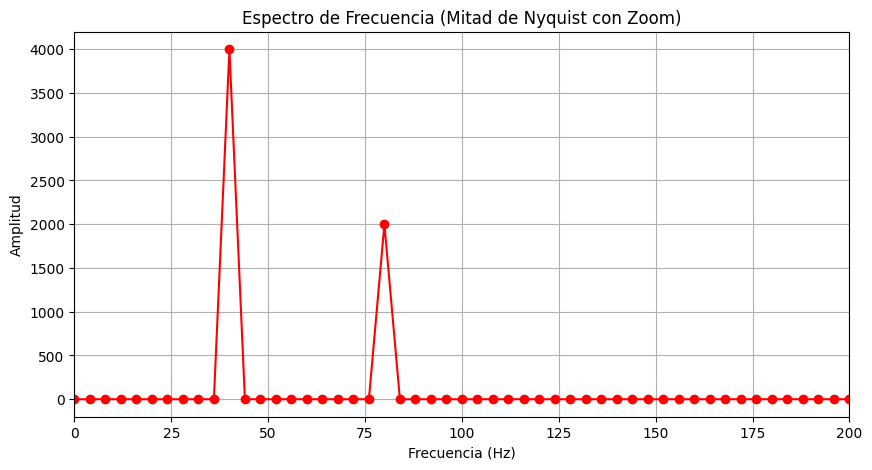

Número total de muestras (N): 800
Altura de los picos en el gráfico: 2000.0


In [23]:
# Un periodo de la fundamental es Tp = 1/40 = 0.025s
# Para 10 periodos la duración total es 10 * Tp = 0.25s
Tp = 1/Fo1 
t_10 = np.arange(0, 10 * Tp, T) 

# Amplitudes de las componentes
A1, A2, A3 = 5, 5, 5

# Generación de la señal suma de las 3 sinusoides
x10 = (A1 * np.sin(2 * np.pi * Fo * t_10) + 
       A2 * np.sin(2 * np.pi * Fo1 * t_10) + 
       A3 * np.sin(2 * np.pi * Fo2* t_10))


# CÁLCULO DE LA TRANSFORMADA DE FOURIER (DFT)
X10 = np.fft.fft(x10)
N = len(X10)  # Número de muestras (800 puntos debido a Fs=3200)
plt.figure(figsize=(10, 5))
plt.plot(abs(X10))
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


# GRÁFICA 1: ESPECTRO COMPLETO ESCALADO EN FRECUENCIA (Como la guía)
F = np.arange(0, N) * Fs / N

plt.figure(figsize=(10, 5))
plt.plot(F, abs(X10), color='blue')
plt.title('Módulos de la DFT (Espectro Completo - 10 Periodos)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0,Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.show()


# GRÁFICA 2: MITAD DE NYQUIST CON ZOOM (Para identificar frecuencias)
Nmitad = int(np.ceil(N / 2))
Fmitad = F[0:Nmitad]
X10mitad = X10[0:Nmitad]

plt.figure(figsize=(10, 5))
plt.plot(Fmitad, abs(X10mitad), marker='o', color='red')
plt.title('Espectro de Frecuencia (Mitad de Nyquist con Zoom)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')

# Hacemos zoom entre 0 y 200 Hz para identificar claramente los 3 picos
plt.xlim(0, 200) 
plt.grid(True)
plt.show()

print(f"Número total de muestras (N): {N}")
print(f"Altura de los picos en el gráfico: {N * 2.5}")

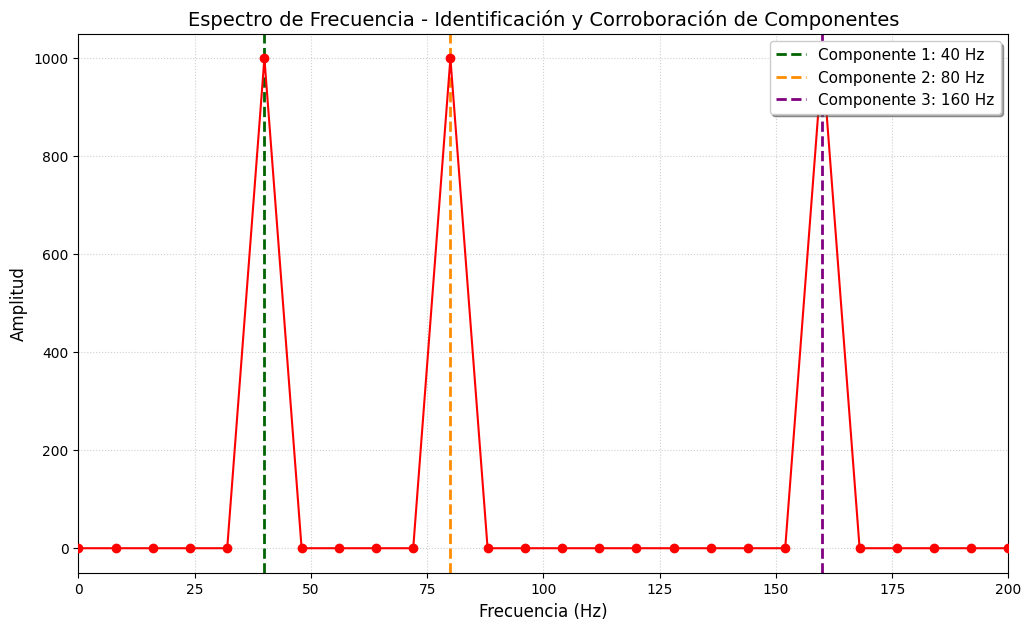

In [11]:
plt.figure(figsize=(12, 7))
plt.plot(Fmitad, abs(X10mitad), marker='o', color='red', linestyle='-', linewidth=1.5, zorder=3)
plt.title('Espectro de Frecuencia - Identificación y Corroboración de Componentes', fontsize=14)
plt.xlabel('Frecuencia (Hz)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.axvline(x=40, color='darkgreen', linestyle='--', linewidth=2, label='Componente 1: 40 Hz', zorder=2)
plt.axvline(x=80, color='darkorange', linestyle='--', linewidth=2, label='Componente 2: 80 Hz', zorder=2)
plt.axvline(x=160, color='purple', linestyle='--', linewidth=2, label='Componente 3: 160 Hz', zorder=2)
plt.xlim(0, 200) 
plt.legend(loc='upper right', fontsize=11, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

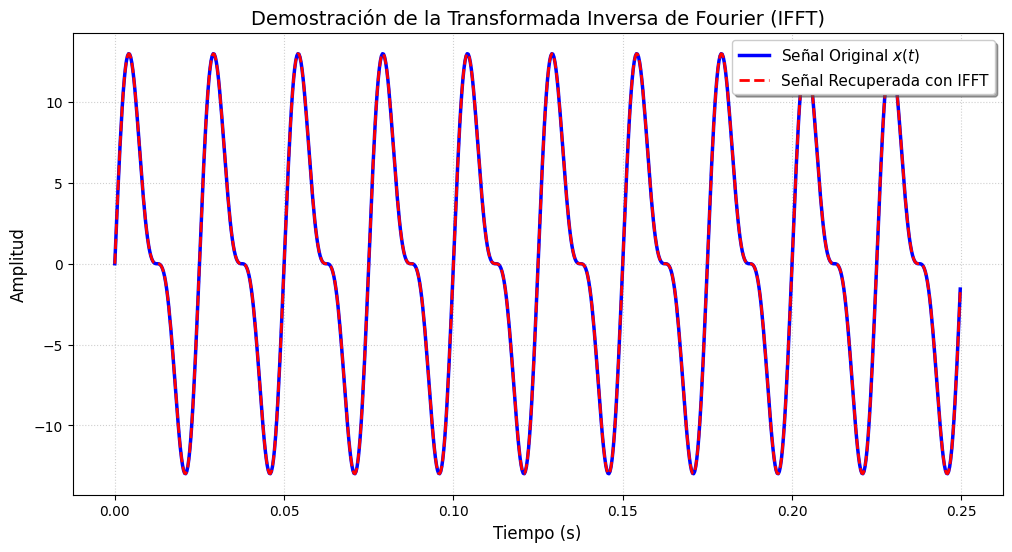

Error máximo de reconstrucción: 7.105427357601002e-15


In [25]:

# 3. TRANSFORMADA INVERSA (IFFT) 
# Aplicamos la transformada inversa al espectro completo
x_reconstruida_compleja = np.fft.ifft(X10)

# Extraemos solo la parte real para limpiar residuos matemáticos insignificantes
x_reconstruida = np.real(x_reconstruida_compleja)

# 4. GRÁFICA DE COMPARACIÓN (COMPROBACIÓN DE RECONSTRUCCIÓN)
plt.figure(figsize=(12, 6))

# Graficamos la señal original con una línea azul continua
plt.plot(t_10, x10, color='blue', label='Señal Original $x(t)$', linewidth=2.5)

# Graficamos la señal reconstruida encima usando puntos rojos discontinuos
plt.plot(t_10, x_reconstruida, color='red', linestyle='--', label='Señal Recuperada con IFFT', linewidth=2)

plt.title('Demostración de la Transformada Inversa de Fourier (IFFT)', fontsize=14)
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(loc='upper right', fontsize=11, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()



# 5. VERIFICACIÓN MATEMÁTICA EN CONSOLA
# Si la diferencia máxima entre ambas señales tiende a cero, la reconstrucción fue perfecta
error_maximo = np.max(np.abs(x10 - x_reconstruida))
print(f"Error máximo de reconstrucción: {error_maximo}")